In [1]:
import pandas as pd
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
print(df.shape)
print(df.dtypes)

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


Check for missing values, duplicates, and dig into that TotalCharges issue

In [2]:
print(df.isnull().sum())
print()
print(df['customerID'].duplicated().sum())
print()
bad_rows = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]
print(bad_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

0

      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00 

In [3]:
print(len(bad_rows))
print((bad_rows['tenure'] == 0).all())
print((bad_rows['Churn'] == 'No').all())

11
True
True


In [4]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df['TotalCharges'].dtype)
print(df.isnull().sum().sum())

float64
0


In [6]:
for col in df.select_dtypes(include='object').columns:
    print(col, '->', df[col].unique())

customerID -> <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender -> <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines -> <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService -> <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection -> <StringArray>
['No', 'Yes', 'No

C:\Users\User\AppData\Local\Temp\ipykernel_27296\783072913.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [7]:
df.select_dtypes(include='object').nunique()

C:\Users\User\AppData\Local\Temp\ipykernel_27296\3404847108.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
Churn                  2
dtype: int64

In [8]:
check_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

for col in check_cols:
    print(col, '->', df[col].unique())

MultipleLines -> <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService -> <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract -> <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
PaymentMethod -> <StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


In [9]:
print(df['Contract'].unique())

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str


In [10]:
# customerID is a unique identifier, not a predictive feature — drop it
df = df.drop('customerID', axis=1)

# True binary columns (exactly 2 values) → map directly to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Multi-category columns (3+ unordered values) → one-hot encode
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(df.shape)
print(df.dtypes)

(7043, 31)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSuppo

In [11]:
print(df.corr()['Churn'].sort_values(ascending=False))

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


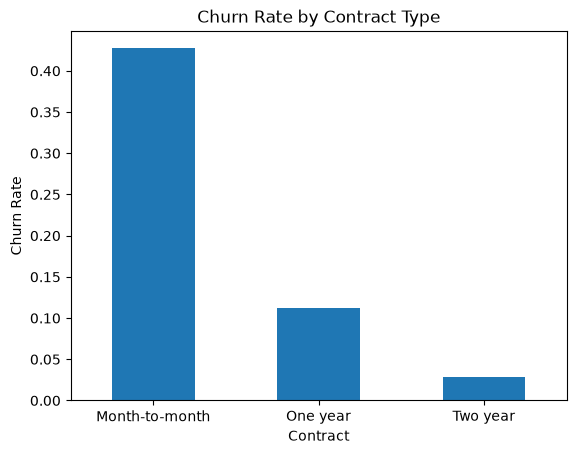

In [33]:
# Fresh copy just for EDA plots — separate from the encoded df we'll use for modeling
df_raw = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce').fillna(0)

import matplotlib.pyplot as plt

contract_churn = df_raw.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean())
print(contract_churn)

contract_churn.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Contract Type')
plt.xticks(rotation=0)
plt.savefig('../reports/figures/churn_by_contract.png', bbox_inches='tight')
plt.show()

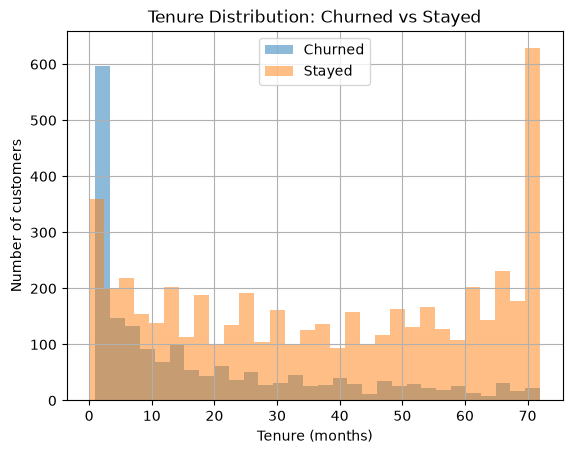

In [13]:
df_raw[df_raw['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.5, label='Churned')
df_raw[df_raw['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.5, label='Stayed')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.legend()
plt.title('Tenure Distribution: Churned vs Stayed')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 30) (1409, 30)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


scale the numeric features

In [15]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train[numeric_cols].describe())

             tenure  MonthlyCharges  TotalCharges
count  5.634000e+03    5.634000e+03  5.634000e+03
mean  -1.008935e-17   -2.402527e-16  2.522338e-17
std    1.000089e+00    1.000089e+00  1.000089e+00
min   -1.322329e+00   -1.544028e+00 -1.008922e+00
25%   -9.559779e-01   -9.711977e-01 -8.321009e-01
50%   -1.418632e-01    1.848336e-01 -3.968446e-01
75%    9.164859e-01    8.319124e-01  6.741944e-01
max    1.608483e+00    1.785939e+00  2.801869e+00


In [16]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 30) (1409, 30) (5634,) (1409,)


In [17]:
# 1. Confirm no missing values anywhere
print("Nulls in X_train:", X_train.isnull().sum().sum())
print("Nulls in X_test:", X_test.isnull().sum().sum())

# 2. Confirm every column is actually numeric (no leftover text)
print("\nNon-numeric columns in X_train:", X_train.select_dtypes(include='object').columns.tolist())

# 3. Confirm X and y rows are still correctly paired after the split
print("\nX_train / y_train aligned:", X_train.index.equals(y_train.index))
print("X_test / y_test aligned:", X_test.index.equals(y_test.index))

# 4. Confirm train and test have the exact same feature columns, in the same order
print("\nTrain/test columns match:", list(X_train.columns) == list(X_test.columns))

# 5. Confirm the target isn't accidentally still sitting inside the features
print("\n'Churn' in X_train columns:", 'Churn' in X_train.columns)

Nulls in X_train: 0
Nulls in X_test: 0

Non-numeric columns in X_train: []

X_train / y_train aligned: True
X_test / y_test aligned: True

Train/test columns match: True

'Churn' in X_train columns: False


baseline model: Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

[[927 108]
 [165 209]]

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8421710713270816


In [19]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_balanced))
print()
print(classification_report(y_test, y_pred_balanced))

[[747 288]
 [ 81 293]]

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [20]:
y_pred_proba_balanced = model_balanced.predict_proba(X_test)[:, 1]
print("ROC-AUC (balanced):", roc_auc_score(y_test, y_pred_proba_balanced))

ROC-AUC (balanced): 0.8417318969748638


In [21]:
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred_t = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Threshold {threshold}: missed={fn}, false_alarms={fp}, precision={precision:.2f}, recall={recall:.2f}")

Threshold 0.3: missed=91, false_alarms=261, precision=0.52, recall=0.76
Threshold 0.35: missed=111, false_alarms=220, precision=0.54, recall=0.70
Threshold 0.4: missed=125, false_alarms=188, precision=0.57, recall=0.67
Threshold 0.45: missed=144, false_alarms=153, precision=0.60, recall=0.61
Threshold 0.5: missed=165, false_alarms=108, precision=0.66, recall=0.56
Threshold 0.55: missed=202, false_alarms=81, precision=0.68, recall=0.46
Threshold 0.6: missed=224, false_alarms=59, precision=0.72, recall=0.40


"The default 0.5 threshold missed 165 of 374 churners (44%). Since failing to flag a customer who leaves is generally costlier than a low-cost retention outreach to someone who was staying anyway, we lowered the decision threshold to 0.45. This catches 21 more churners (144 missed vs. 165) at the cost of 45 more false alarms (153 vs. 108) — a reasonable trade-off given the asymmetry in cost between a missed customer and a wasted email."

In [22]:
FINAL_THRESHOLD = 0.45
y_pred_final = (y_pred_proba >= FINAL_THRESHOLD).astype(int)

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[882 153]
 [144 230]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1035
           1       0.60      0.61      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))

[[928 107]
 [188 186]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8240215453770441


In [24]:
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_t = (y_pred_proba_rf >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Threshold {threshold}: missed={fn}, false_alarms={fp}, precision={precision:.2f}, recall={recall:.2f}")

Threshold 0.3: missed=107, false_alarms=251, precision=0.52, recall=0.71
Threshold 0.35: missed=122, false_alarms=214, precision=0.54, recall=0.67
Threshold 0.4: missed=141, false_alarms=176, precision=0.57, recall=0.62
Threshold 0.45: missed=160, false_alarms=140, precision=0.60, recall=0.57
Threshold 0.5: missed=184, false_alarms=108, precision=0.64, recall=0.51


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, scoring='roc_auc', cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_pred_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))
print("Test ROC-AUC:", roc_auc_score(y_test, y_pred_best_rf))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 300}
Best CV ROC-AUC: 0.8470176062128207
[[768 267]
 [ 80 294]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409

Test ROC-AUC: 0.7640626210958692


In [26]:
print("Test ROC-AUC (correct):", roc_auc_score(y_test, y_pred_proba_best_rf))

Test ROC-AUC (correct): 0.8444108605233925


In [27]:
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_t = (y_pred_proba_best_rf >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Threshold {threshold}: missed={fn}, false_alarms={fp}, precision={precision:.2f}, recall={recall:.2f}")

Threshold 0.3: missed=36, false_alarms=455, precision=0.43, recall=0.90
Threshold 0.35: missed=44, false_alarms=410, precision=0.45, recall=0.88
Threshold 0.4: missed=54, false_alarms=350, precision=0.48, recall=0.86
Threshold 0.45: missed=61, false_alarms=305, precision=0.51, recall=0.84
Threshold 0.5: missed=80, false_alarms=267, precision=0.52, recall=0.79


In [28]:
import joblib

FINAL_THRESHOLD_RF = 0.35
y_pred_final_rf = (y_pred_proba_best_rf >= FINAL_THRESHOLD_RF).astype(int)

print(confusion_matrix(y_test, y_pred_final_rf))
print(classification_report(y_test, y_pred_final_rf))

joblib.dump(best_rf, '../models/random_forest_final.pkl')
joblib.dump(model, '../models/logistic_regression_baseline.pkl')

[[625 410]
 [ 44 330]]
              precision    recall  f1-score   support

           0       0.93      0.60      0.73      1035
           1       0.45      0.88      0.59       374

    accuracy                           0.68      1409
   macro avg       0.69      0.74      0.66      1409
weighted avg       0.80      0.68      0.70      1409



['../models/logistic_regression_baseline.pkl']

In [29]:
import os
print(os.listdir('../models'))

['logistic_regression_baseline.pkl', 'random_forest_final.pkl']


model interpretation — Random Forest's feature importances.

tenure                                 0.183895
TotalCharges                           0.131593
Contract_Two year                      0.110678
InternetService_Fiber optic            0.078917
MonthlyCharges                         0.077711
PaymentMethod_Electronic check         0.059093
Contract_One year                      0.042690
OnlineSecurity_Yes                     0.036625
TechSupport_Yes                        0.028789
StreamingTV_No internet service        0.021533
StreamingMovies_No internet service    0.021432
OnlineSecurity_No internet service     0.020322
PaperlessBilling                       0.018308
OnlineBackup_No internet service       0.017858
TechSupport_No internet service        0.017590
dtype: float64


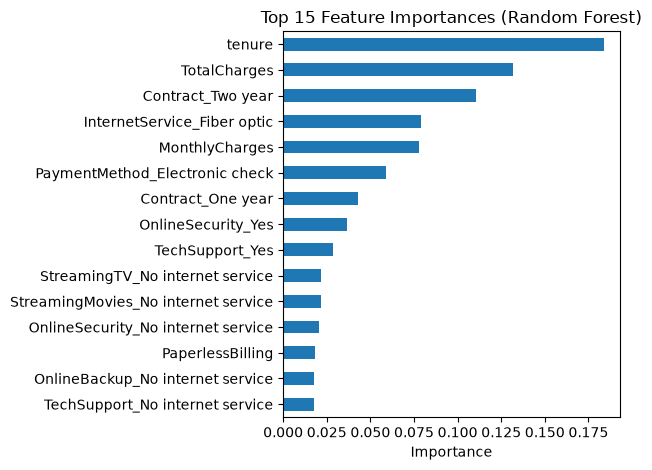

In [30]:
import pandas as pd

importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(15))

importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

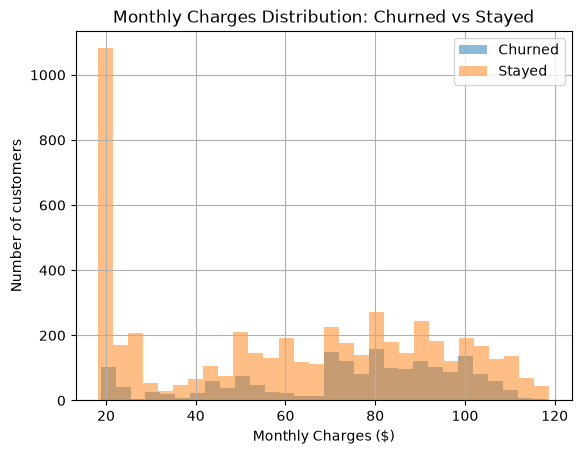

In [31]:
df_raw[df_raw['Churn'] == 'Yes']['MonthlyCharges'].hist(bins=30, alpha=0.5, label='Churned')
df_raw[df_raw['Churn'] == 'No']['MonthlyCharges'].hist(bins=30, alpha=0.5, label='Stayed')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of customers')
plt.legend()
plt.title('Monthly Charges Distribution: Churned vs Stayed')
plt.show()

charge_bucket
(0, 30]      0.098004
(30, 60]     0.259289
(60, 90]     0.339061
(90, 120]    0.327775
Name: Churn, dtype: float64


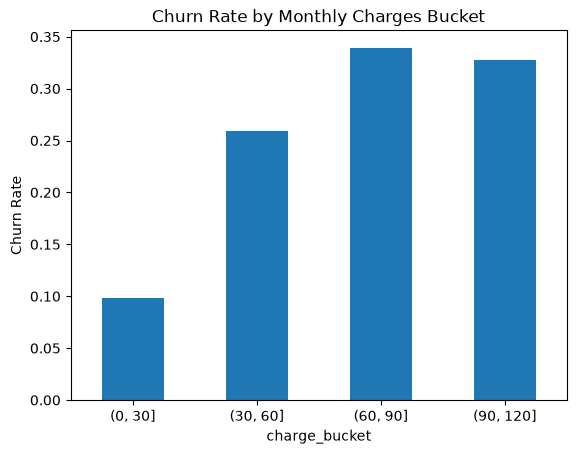

In [32]:
df_raw['charge_bucket'] = pd.cut(df_raw['MonthlyCharges'], bins=[0, 30, 60, 90, 120])
charge_churn = df_raw.groupby('charge_bucket')['Churn'].apply(lambda x: (x == 'Yes').mean())
print(charge_churn)

charge_churn.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Monthly Charges Bucket')
plt.xticks(rotation=0)
plt.show()